This model is very similar to 23 but instead of using the DINOv2 base, this one will instead make use of the larger DINOv2 large which was the same one used for Model 3 V3 DinoV2

Use prepared datasets from model 23 since we are just swapping out the backbone for a larger one

In [ ]:
# =========================================================
# MODEL 24 - GPU PART
# Full RDINet-style 3-level RGB-D model using PyTorch
# RGB branch:   DINOv2_large
# Depth branch: DINOv2_large
# Depth image:  depth_color.png
# Target:       total_carb only
# =========================================================

!pip install -q transformers accelerate timm tqdm

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import os
import json
import math
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import Dinov2Model
from tqdm.auto import tqdm

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

Mounted at /content/drive
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA L4


Configuration

In [ ]:
MODEL_NAME = "Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor"

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Speciale/Models/"
    "Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Reuse Model 23 prepared CSVs
PREP_DIR = Path(
    "/content/drive/MyDrive/Speciale/Models/Model_23_RDINet_3Level_DINOv2_RGB_DINOv2_depthcolor/prep_files"
)

train_csv = PREP_DIR / "train_model23.csv"
val_csv   = PREP_DIR / "val_model23.csv"
test_csv  = PREP_DIR / "test_model23.csv"

DINO_CHECKPOINT = "facebook/dinov2-large"

IMG_SIZE = 224

BATCH_SIZE = 16

STAGE1_EPOCHS = 100
STAGE2_EPOCHS = 150

# Slightly safer for larger model/fusion head
STAGE1_LR = 1e-4
STAGE2_LR = 2e-6

WEIGHT_DECAY = 1e-4

# DINOv2-large has 24 transformer blocks: 0-23
SELECTED_DINO_LAYERS = [3, 11, 23]

FUSION_CHANNELS = 1024

N_UNFROZEN_BLOCKS = 4

NUM_WORKERS = 0
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)
print("Output dir:", OUTPUT_DIR)
print("CSV dir:", PREP_DIR)
print("DINO checkpoint:", DINO_CHECKPOINT)

Device: cuda
Output dir: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor
CSV dir: /content/drive/MyDrive/Speciale/Models/Model_23_RDINet_3Level_DINOv2_RGB_DINOv2_depthcolor/prep_files
DINO checkpoint: facebook/dinov2-large


Loading prepared CSV

In [ ]:
train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

for d in [train_df, val_df, test_df]:
    d["dish_id"] = d["dish_id"].astype(str).str.strip()
    d["rgb_path"] = d["rgb_path"].astype(str)
    d["depth_path"] = d["depth_path"].astype(str)
    d["total_carb"] = pd.to_numeric(d["total_carb"], errors="coerce").astype("float32")

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

display(train_df.head())

Train: 2419
Val:   334
Test:  507


,dish_id,total_carb,split,source_cafe,rgb_path,depth_path,rgb_exists,depth_exists,rgb_size,depth_size
0,dish_1556572657,2.268,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,412129,128124
1,dish_1556573514,1.219,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,432908,286439
2,dish_1556575014,3.906,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,409854,300120
3,dish_1556575083,5.760,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,396942,288910
4,dish_1556575124,0.952,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,404314,287977


Image loading

In [ ]:
class RGBDepthCarbDataset(Dataset):
    def __init__(self, dataframe, img_size=224):
        self.df = dataframe.reset_index(drop=True)
        self.img_size = img_size

        # Standard ImageNet/DINO-style normalization
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self):
        return len(self.df)

    def resize_with_pad_pil(self, img):
        img = ImageOps.contain(
            img,
            (self.img_size, self.img_size),
            method=Image.BILINEAR,
        )

        padded = Image.new("RGB", (self.img_size, self.img_size), (0, 0, 0))
        paste_x = (self.img_size - img.size[0]) // 2
        paste_y = (self.img_size - img.size[1]) // 2
        padded.paste(img, (paste_x, paste_y))

        return padded

    def load_image(self, path):
        img = Image.open(path).convert("RGB")
        img = self.resize_with_pad_pil(img)

        arr = np.asarray(img).astype("float32") / 255.0
        arr = np.transpose(arr, (2, 0, 1))  # HWC -> CHW

        tensor = torch.from_numpy(arr)
        tensor = (tensor - self.mean) / self.std

        return tensor

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        rgb = self.load_image(row["rgb_path"])
        depth = self.load_image(row["depth_path"])

        target = torch.tensor(row["total_carb"], dtype=torch.float32)

        return {
            "rgb": rgb,
            "depth": depth,
            "target": target,
            "dish_id": row["dish_id"],
        }


train_dataset = RGBDepthCarbDataset(train_df, img_size=IMG_SIZE)
val_dataset   = RGBDepthCarbDataset(val_df, img_size=IMG_SIZE)
test_dataset  = RGBDepthCarbDataset(test_df, img_size=IMG_SIZE)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

batch = next(iter(train_loader))
print("RGB:", batch["rgb"].shape)
print("Depth:", batch["depth"].shape)
print("Target:", batch["target"].shape)
print("Example dish IDs:", batch["dish_id"][:3])

RGB: torch.Size([16, 3, 224, 224])
Depth: torch.Size([16, 3, 224, 224])
Target: torch.Size([16])
Example dish IDs: ['dish_1558720335', 'dish_1563220171', 'dish_1558460205']


Checking for correct load in

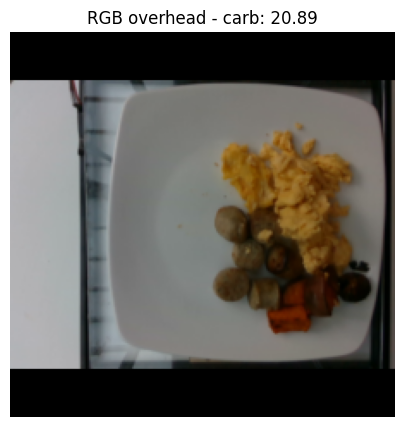

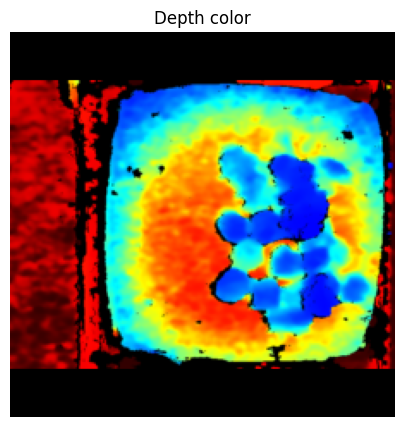

In [ ]:
def denormalize_img(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    img = tensor.cpu() * std + mean
    img = torch.clamp(img, 0, 1)
    img = img.permute(1, 2, 0).numpy()

    return img


batch = next(iter(train_loader))

rgb_img = denormalize_img(batch["rgb"][0])
depth_img = denormalize_img(batch["depth"][0])
target = float(batch["target"][0].item())

plt.figure(figsize=(5, 5))
plt.imshow(rgb_img)
plt.title(f"RGB overhead - carb: {target:.2f}")
plt.axis("off")
plt.show()

plt.figure(figsize=(5, 5))
plt.imshow(depth_img)
plt.title("Depth color")
plt.axis("off")
plt.show()

DINOv2 preprocessing

In [ ]:
def tokens_to_spatial_map(tokens):
    """
    tokens:
        B x N x C

    DINOv2 has CLS token first:
        N = 1 + patch_tokens

    For 224x224 and patch size 14:
        patch grid = 16 x 16
    """

    # Remove CLS token
    patch_tokens = tokens[:, 1:, :]

    batch_size, num_tokens, channels = patch_tokens.shape
    side = int(math.sqrt(num_tokens))

    if side * side != num_tokens:
        raise ValueError(
            f"Patch tokens cannot form square map. "
            f"num_tokens={num_tokens}, side={side}"
        )

    # B x N x C -> B x C x H x W
    feat_map = patch_tokens.transpose(1, 2).reshape(
        batch_size,
        channels,
        side,
        side,
    )

    return feat_map

In [ ]:
class ChannelSpatialAttentionFusion(nn.Module):
    def __init__(self, in_channels=768, out_channels=768, reduction=4):
        super().__init__()

        self.out_channels = out_channels

        self.rgb_project = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

        self.depth_project = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

        reduced_channels = max(out_channels // reduction, 16)

        self.channel_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(out_channels * 2, reduced_channels, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduced_channels, out_channels * 2, kernel_size=1),
            nn.Sigmoid(),
        )

        self.spatial_attention = nn.Sequential(
            nn.Conv2d(out_channels * 2, 1, kernel_size=7, padding=3),
            nn.Sigmoid(),
        )

    def forward(self, rgb_feat, depth_feat):
        rgb_proj = self.rgb_project(rgb_feat)
        depth_proj = self.depth_project(depth_feat)

        concat = torch.cat([rgb_proj, depth_proj], dim=1)

        channel_weights = self.channel_attention(concat)
        spatial_weight = self.spatial_attention(concat)

        rgb_channel_weight = channel_weights[:, :self.out_channels, :, :]
        depth_channel_weight = channel_weights[:, self.out_channels:, :, :]

        rgb_weighted = rgb_proj * rgb_channel_weight * spatial_weight
        depth_weighted = depth_proj * depth_channel_weight * spatial_weight

        fused = torch.cat([rgb_weighted, depth_weighted], dim=1)

        return fused

Multi-level feature integration block

In [ ]:
class MultiLevelFeatureIntegration(nn.Module):
    def __init__(self, fusion_channels=768):
        super().__init__()

        self.level_projectors = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(fusion_channels * 2, fusion_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(fusion_channels),
                nn.ReLU(inplace=True),
            )
            for _ in range(3)
        ])

        self.final_project = nn.Sequential(
            nn.Conv2d(fusion_channels * 3, fusion_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(fusion_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, fused_levels):
        projected = []

        for feat, projector in zip(fused_levels, self.level_projectors):
            projected.append(projector(feat))

        x = torch.cat(projected, dim=1)
        x = self.final_project(x)

        return x

Building full model 24

In [ ]:
class Model24_RDINet_DINOv2_RGBD(nn.Module):
    def __init__(
        self,
        checkpoint="facebook/dinov2-base",
        selected_layers=[0, 6, 11],
        fusion_channels=768,
        dropout_1=0.40,
        dropout_2=0.30,
    ):
        super().__init__()

        self.selected_layers = selected_layers

        self.rgb_backbone = Dinov2Model.from_pretrained(checkpoint)
        self.depth_backbone = Dinov2Model.from_pretrained(checkpoint)

        hidden_size = self.rgb_backbone.config.hidden_size

        self.rgb_level_norms = nn.ModuleList([
            nn.LayerNorm(hidden_size)
            for _ in selected_layers
        ])

        self.depth_level_norms = nn.ModuleList([
            nn.LayerNorm(hidden_size)
            for _ in selected_layers
        ])

        self.fusion_blocks = nn.ModuleList([
            ChannelSpatialAttentionFusion(
                in_channels=hidden_size,
                out_channels=fusion_channels,
                reduction=4,
            )
            for _ in selected_layers
        ])

        self.multi_level_integration = MultiLevelFeatureIntegration(
            fusion_channels=fusion_channels
        )

        self.regression_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),

            nn.LayerNorm(fusion_channels),

            nn.Linear(fusion_channels, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_1),

            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_2),

            nn.Linear(256, 64),
            nn.ReLU(inplace=True),

            nn.Linear(64, 1),
        )

    def forward(self, rgb, depth):
        rgb_outputs = self.rgb_backbone(
            pixel_values=rgb,
            output_hidden_states=True,
            return_dict=True,
        )

        depth_outputs = self.depth_backbone(
            pixel_values=depth,
            output_hidden_states=True,
            return_dict=True,
        )

        rgb_hidden_states = rgb_outputs.hidden_states
        depth_hidden_states = depth_outputs.hidden_states

        fused_levels = []

        for i, layer_idx in enumerate(self.selected_layers):
            # hidden_states[0] is embedding output.
            # transformer block 0 is hidden_states[1].
            hidden_state_idx = layer_idx + 1

            rgb_tokens = rgb_hidden_states[hidden_state_idx]
            depth_tokens = depth_hidden_states[hidden_state_idx]

            rgb_tokens = self.rgb_level_norms[i](rgb_tokens)
            depth_tokens = self.depth_level_norms[i](depth_tokens)

            rgb_map = tokens_to_spatial_map(rgb_tokens)
            depth_map = tokens_to_spatial_map(depth_tokens)

            fused = self.fusion_blocks[i](rgb_map, depth_map)
            fused_levels.append(fused)

        rgbd_feature_map = self.multi_level_integration(fused_levels)

        carb_pred = self.regression_head(rgbd_feature_map)
        carb_pred = carb_pred.squeeze(1)

        return carb_pred

Freeze unfreeze helpers

In [ ]:
def freeze_backbone(backbone):
    for param in backbone.parameters():
        param.requires_grad = False


def unfreeze_last_dinov2_blocks(backbone, n_blocks=2, name="backbone"):
    """
    Unfreezes the last n transformer encoder blocks.
    For DINOv2-base, there are 12 blocks: 0-11.
    """

    freeze_backbone(backbone)

    layers = backbone.encoder.layer
    total_blocks = len(layers)
    start_idx = max(0, total_blocks - n_blocks)

    for i in range(start_idx, total_blocks):
        for param in layers[i].parameters():
            param.requires_grad = True

    print("=" * 80)
    print(name)
    print("Total encoder blocks:", total_blocks)
    print("Unfrozen blocks:", list(range(start_idx, total_blocks)))


def count_trainable_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())

    print(f"Trainable params: {trainable:,}")
    print(f"Total params:     {total:,}")
    print(f"Trainable %:      {100 * trainable / total:.2f}%")


def set_backbones_frozen(model):
    freeze_backbone(model.rgb_backbone)
    freeze_backbone(model.depth_backbone)


def set_backbones_stage2_unfreeze(model, n_blocks=2):
    unfreeze_last_dinov2_blocks(
        model.rgb_backbone,
        n_blocks=n_blocks,
        name="RGB DINOv2",
    )

    unfreeze_last_dinov2_blocks(
        model.depth_backbone,
        n_blocks=n_blocks,
        name="Depth DINOv2",
    )

building full model

In [ ]:
model = Model24_RDINet_DINOv2_RGBD(
    checkpoint=DINO_CHECKPOINT,
    selected_layers=SELECTED_DINO_LAYERS,
    fusion_channels=FUSION_CHANNELS,
    dropout_1=0.40,
    dropout_2=0.30,
).to(DEVICE)

# Stage 1: freeze both DINOv2 backbones
set_backbones_frozen(model)

count_trainable_params(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/549 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

Trainable params: 19,889,796
Total params:     628,627,076
Trainable %:      3.16%


Training/evaluation helper functions

In [ ]:
def move_batch_to_device(batch, device):
    rgb = batch["rgb"].to(device, non_blocking=True)
    depth = batch["depth"].to(device, non_blocking=True)
    target = batch["target"].to(device, non_blocking=True)

    return rgb, depth, target


def compute_metrics_from_arrays(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)

    errors = y_pred - y_true

    mse = float(np.mean(errors ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(errors)))

    return {
        "loss": mse,
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
    }


def evaluate_model(model, loader, device):
    model.eval()

    all_targets = []
    all_preds = []

    total_loss = 0.0
    total_n = 0

    criterion = nn.MSELoss(reduction="sum")

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            rgb, depth, target = move_batch_to_device(batch, device)

            pred = model(rgb, depth)

            loss = criterion(pred, target)

            batch_size = target.size(0)
            total_loss += loss.item()
            total_n += batch_size

            all_targets.append(target.detach().cpu().numpy())
            all_preds.append(pred.detach().cpu().numpy())

    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)

    metrics = compute_metrics_from_arrays(y_true, y_pred)
    metrics["loss"] = total_loss / total_n

    return metrics, y_true, y_pred


def train_one_epoch(model, loader, optimizer, scaler, device):
    model.train()

    total_loss = 0.0
    total_abs_error = 0.0
    total_n = 0

    criterion = nn.MSELoss(reduction="mean")

    pbar = tqdm(loader, desc="Training", leave=False)

    for batch in pbar:
        rgb, depth, target = move_batch_to_device(batch, device)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            pred = model(rgb, depth)
            loss = criterion(pred, target)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = target.size(0)

        total_loss += loss.item() * batch_size
        total_abs_error += torch.sum(torch.abs(pred.detach() - target)).item()
        total_n += batch_size

        pbar.set_postfix({
            "loss": total_loss / total_n,
            "mae": total_abs_error / total_n,
        })

    return {
        "loss": total_loss / total_n,
        "mae": total_abs_error / total_n,
        "mse": total_loss / total_n,
    }


def save_checkpoint(path, model, optimizer, epoch, best_val_loss, config_dict):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_loss": best_val_loss,
        "config": config_dict,
    }

    torch.save(checkpoint, path)


def load_checkpoint(path, model, device):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    return checkpoint

General train loop

In [ ]:
def run_training_stage(
    model,
    train_loader,
    val_loader,
    device,
    epochs,
    lr,
    weight_decay,
    checkpoint_path,
    stage_name,
    patience=50,
    min_lr=1e-7,
):
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=35,
        min_lr=min_lr,
    )

    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    history = {
        "loss": [],
        "mae": [],
        "mse": [],
        "val_loss": [],
        "val_mae": [],
        "val_mse": [],
        "lr": [],
    }

    best_val_loss = float("inf")
    best_epoch = -1
    wait = 0

    config_dict = {
        "model_name": MODEL_NAME,
        "stage_name": stage_name,
        "dino_checkpoint": DINO_CHECKPOINT,
        "selected_dino_layers": SELECTED_DINO_LAYERS,
        "fusion_channels": FUSION_CHANNELS,
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "lr": lr,
        "weight_decay": weight_decay,
    }

    for epoch in range(1, epochs + 1):
        print(f"\n{stage_name} - Epoch {epoch}/{epochs}")

        train_metrics = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
        )

        val_metrics, _, _ = evaluate_model(
            model=model,
            loader=val_loader,
            device=device,
        )

        scheduler.step(val_metrics["loss"])

        current_lr = optimizer.param_groups[0]["lr"]

        history["loss"].append(train_metrics["loss"])
        history["mae"].append(train_metrics["mae"])
        history["mse"].append(train_metrics["mse"])

        history["val_loss"].append(val_metrics["loss"])
        history["val_mae"].append(val_metrics["mae"])
        history["val_mse"].append(val_metrics["mse"])

        history["lr"].append(current_lr)

        print(
            f"train_loss={train_metrics['loss']:.4f} | "
            f"train_mae={train_metrics['mae']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_mae={val_metrics['mae']:.4f} | "
            f"lr={current_lr:.2e}"
        )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_epoch = epoch
            wait = 0

            save_checkpoint(
                path=checkpoint_path,
                model=model,
                optimizer=optimizer,
                epoch=epoch,
                best_val_loss=best_val_loss,
                config_dict=config_dict,
            )

            print(f"Saved new best checkpoint: {checkpoint_path}")
        else:
            wait += 1

        if wait >= patience:
            print(f"Early stopping after {epoch} epochs.")
            break

    print(f"\nBest {stage_name} epoch:", best_epoch)
    print(f"Best {stage_name} val_loss:", best_val_loss)

    return history, best_val_loss

Training stage 1

In [ ]:
stage1_best_path = OUTPUT_DIR / "best_stage1.pt"

history_stage1, stage1_min_val_loss = run_training_stage(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    epochs=STAGE1_EPOCHS,
    lr=STAGE1_LR,
    weight_decay=WEIGHT_DECAY,
    checkpoint_path=stage1_best_path,
    stage_name="Stage 1",
    patience=50,
    min_lr=1e-6,
)


Stage 1 - Epoch 1/100


/tmp/ipykernel_26704/668794712.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


Training:   0%|          | 0/152 [00:00<?, ?it/s]

/tmp/ipykernel_26704/2125587680.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]

train_loss=15.2834 | train_mae=2.0462 | val_loss=43.9290 | val_mae=4.6491 | lr=5.00e-05

Stage 1 - Epoch 100/100


Training:   0%|          | 0/152 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]

train_loss=13.2178 | train_mae=2.0010 | val_loss=43.4715 | val_mae=4.5692 | lr=5.00e-05

Best Stage 1 epoch: 59
Best Stage 1 val_loss: 38.8870215044764


Evaluating stage 1

In [ ]:
load_checkpoint(stage1_best_path, model, DEVICE)

stage1_test_results, stage1_y_true, stage1_y_pred = evaluate_model(
    model=model,
    loader=test_loader,
    device=DEVICE,
)

test_mean_carb = float(test_df["total_carb"].mean())
stage1_pmae = 100.0 * float(stage1_test_results["mae"]) / test_mean_carb

print("Stage 1 test results:")
for k, v in stage1_test_results.items():
    print(f"{k}: {v:.4f}")

print(f"Test mean carb: {test_mean_carb:.4f}")
print(f"Stage 1 PMAE:   {stage1_pmae:.2f}%")

Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

Stage 1 test results:
loss: 53.8922
mse: 53.8922
rmse: 7.3411
mae: 4.7191
Test mean carb: 19.6836
Stage 1 PMAE:   23.97%


Stage 2 unfreezing and training

In [ ]:
load_checkpoint(stage1_best_path, model, DEVICE)

set_backbones_stage2_unfreeze(
    model,
    n_blocks=N_UNFROZEN_BLOCKS,
)

count_trainable_params(model)

RGB DINOv2
Total encoder blocks: 24
Unfrozen blocks: [20, 21, 22, 23]
Depth DINOv2
Total encoder blocks: 24
Unfrozen blocks: [20, 21, 22, 23]
Trainable params: 120,675,972
Total params:     628,627,076
Trainable %:      19.20%


In [ ]:
stage2_best_path = OUTPUT_DIR / "best_stage2.pt"

history_stage2, stage2_min_val_loss = run_training_stage(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    epochs=STAGE2_EPOCHS,
    lr=STAGE2_LR,
    weight_decay=WEIGHT_DECAY,
    checkpoint_path=stage2_best_path,
    stage_name="Stage 2",
    patience=75,
    min_lr=1e-7,
)


Stage 2 - Epoch 1/150


/tmp/ipykernel_26704/668794712.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


Training:   0%|          | 0/152 [00:00<?, ?it/s]

/tmp/ipykernel_26704/2125587680.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]

...

Training:   0%|          | 0/152 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]

train_loss=25.4812 | train_mae=2.4360 | val_loss=43.1406 | val_mae=4.4527 | lr=2.00e-06

Stage 2 - Epoch 5/150


Training:   0%|          | 0/152 [00:00<?, ?it/s]

KeyboardInterrupt: 

Evaluating stage 2

In [ ]:
load_checkpoint(stage2_best_path, model, DEVICE)

stage2_test_results, stage2_y_true, stage2_y_pred = evaluate_model(
    model=model,
    loader=test_loader,
    device=DEVICE,
)

stage2_pmae = 100.0 * float(stage2_test_results["mae"]) / test_mean_carb

print("Stage 2 test results:")
for k, v in stage2_test_results.items():
    print(f"{k}: {v:.4f}")

print(f"Test mean carb: {test_mean_carb:.4f}")
print(f"Stage 2 PMAE:   {stage2_pmae:.2f}%")

Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

Stage 2 test results:
loss: 57.0820
mse: 57.0820
rmse: 7.5553
mae: 4.7247
Test mean carb: 19.6836
Stage 2 PMAE:   24.00%


Comparing the two stages

In [ ]:
comparison_df = pd.DataFrame([
    {
        "stage": "stage_1",
        "best_val_loss": float(stage1_min_val_loss),
        "test_loss": float(stage1_test_results["loss"]),
        "test_mae": float(stage1_test_results["mae"]),
        "test_mse": float(stage1_test_results["mse"]),
        "test_pmae": float(stage1_pmae),
        "checkpoint_path": str(stage1_best_path),
    },
    {
        "stage": "stage_2",
        "best_val_loss": float(stage2_min_val_loss),
        "test_loss": float(stage2_test_results["loss"]),
        "test_mae": float(stage2_test_results["mae"]),
        "test_mse": float(stage2_test_results["mse"]),
        "test_pmae": float(stage2_pmae),
        "checkpoint_path": str(stage2_best_path),
    },
])

display(comparison_df)

comparison_csv = OUTPUT_DIR / "stage_comparison.csv"
comparison_df.to_csv(comparison_csv, index=False)

best_stage_row = comparison_df.sort_values("best_val_loss", ascending=True).iloc[0]
best_stage = best_stage_row["stage"]
best_checkpoint_path = Path(best_stage_row["checkpoint_path"])

print("Best stage by val_loss:", best_stage)
print("Best checkpoint:", best_checkpoint_path)

NameError: name 'stage2_min_val_loss' is not defined

Loading best model

In [ ]:
load_checkpoint(best_checkpoint_path, model, DEVICE)

print("Loaded best model:", best_stage)

NameError: name 'best_checkpoint_path' is not defined

Saving predictions

In [ ]:
best_test_results, y_true, y_pred = evaluate_model(
    model=model,
    loader=test_loader,
    device=DEVICE,
)

test_eval_df = test_df.copy().reset_index(drop=True)
test_eval_df["prediction"] = y_pred
test_eval_df["abs_error"] = np.abs(test_eval_df["total_carb"].values - y_pred)
test_eval_df["signed_error"] = y_pred - test_eval_df["total_carb"].values

pred_csv = OUTPUT_DIR / f"test_predictions_{best_stage}.csv"
test_eval_df.to_csv(pred_csv, index=False)

print("Saved:", pred_csv)
display(test_eval_df.head())

print("Best model test results:")
for k, v in best_test_results.items():
    print(f"{k}: {v:.4f}")

best_pmae = 100.0 * best_test_results["mae"] / test_mean_carb
print(f"Best model PMAE: {best_pmae:.2f}%")

Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

NameError: name 'best_stage' is not defined

Top 10 best and worst predictions

In [ ]:
best_10 = test_eval_df.sort_values("abs_error", ascending=True).head(10)
worst_10 = test_eval_df.sort_values("abs_error", ascending=False).head(10)

print("Best 10 predictions:")
display(best_10[["dish_id", "total_carb", "prediction", "abs_error", "signed_error"]])

print("Worst 10 predictions:")
display(worst_10[["dish_id", "total_carb", "prediction", "abs_error", "signed_error"]])

best_10.to_csv(OUTPUT_DIR / f"best10_predictions_{best_stage}.csv", index=False)
worst_10.to_csv(OUTPUT_DIR / f"worst10_predictions_{best_stage}.csv", index=False)

Best 10 predictions:


,dish_id,total_carb,prediction,abs_error,signed_error
21,dish_1558030435,24.954000,24.949890,0.004110,-0.004110
106,dish_1558722125,19.521999,19.516399,0.005600,-0.005600
37,dish_1558114209,7.200000,7.214369,0.014369,0.014369
401,dish_1565118700,3.111500,3.139919,0.028419,0.028419
382,dish_1565020796,0.749000,0.719130,0.029870,-0.029870
111,dish_1559157777,0.396000,0.426793,0.030793,0.030793
416,dish_1565810969,0.720000,0.684008,0.035992,-0.035992
168,dish_1560526408,2.743767,2.779990,0.036223,0.036223
54,dish_1558376801,0.795000,0.842269,0.047269,0.047269
505,dish_1568401261,34.582966,34.522999,0.059967,-0.059967


Worst 10 predictions:


,dish_id,total_carb,prediction,abs_error,signed_error
178,dish_1560801020,61.690983,22.568241,39.122742,-39.122742
177,dish_1560800988,61.249092,25.728165,35.520927,-35.520927
454,dish_1566501594,54.281998,20.137091,34.144905,-34.144905
424,dish_1565894910,67.945007,36.696827,31.248180,-31.248180
179,dish_1560801041,63.245892,33.408871,29.837021,-29.837021
326,dish_1563566939,48.869175,21.044792,27.824383,-27.824383
149,dish_1560367952,45.956913,18.787136,27.169777,-27.169777
327,dish_1563566965,56.243797,29.715950,26.527847,-26.527847
325,dish_1563566909,46.750000,20.539230,26.210770,-26.210770
247,dish_1562009934,62.243580,36.737022,25.506557,-25.506557


NameError: name 'best_stage' is not defined

Plotting training and validation curves

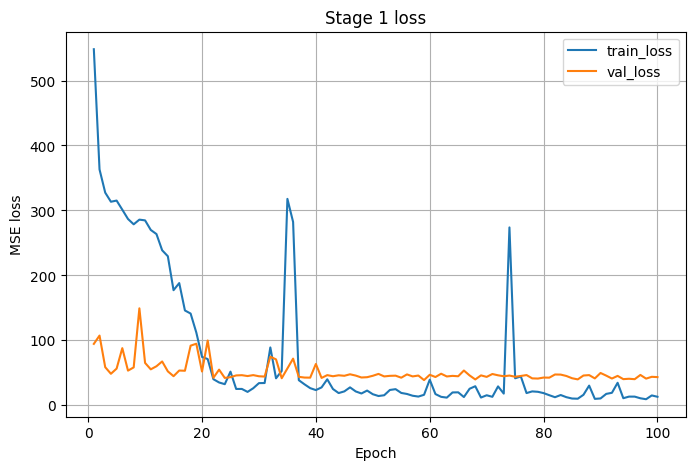

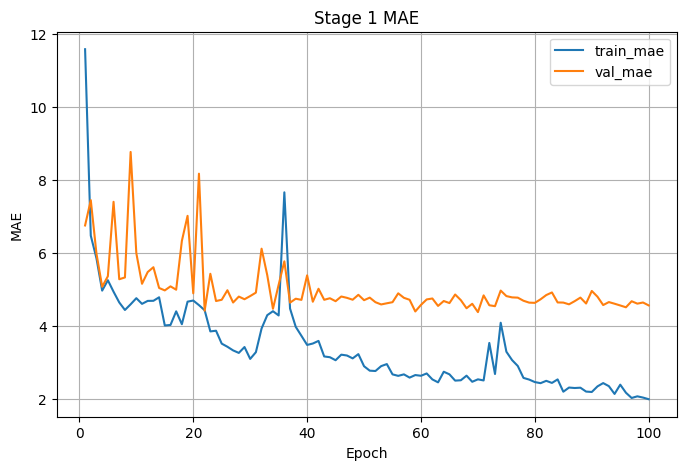

NameError: name 'history_stage2' is not defined

In [ ]:
def plot_history(history, title):
    epochs = range(1, len(history["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.title(f"{title} loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["mae"], label="train_mae")
    plt.plot(epochs, history["val_mae"], label="val_mae")
    plt.title(f"{title} MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_history(history_stage1, "Stage 1")
plot_history(history_stage2, "Stage 2")

Saving summary file

In [ ]:
summary = {
    "model_name": MODEL_NAME,
    "architecture": "RDINet-style 3-level RGB-D fusion using DINOv2 for both RGB and depth_color branches",
    "framework": "PyTorch",
    "rgb_backbone": DINO_CHECKPOINT,
    "depth_backbone": DINO_CHECKPOINT,
    "depth_image_type": "depth_color.png",
    "target": "total_carb",
    "selected_dinov2_layers": SELECTED_DINO_LAYERS,
    "fusion_channels": FUSION_CHANNELS,
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "bad_dishes_removed": [
        "dish_1559172356",
        "dish_1564588719",
    ],
    "test_mean_carb": float(test_mean_carb),
    "stage1": {
        "best_val_loss": float(stage1_min_val_loss),
        "test_loss": float(stage1_test_results["loss"]),
        "test_mae": float(stage1_test_results["mae"]),
        "test_mse": float(stage1_test_results["mse"]),
        "test_pmae": float(stage1_pmae),
        "checkpoint_path": str(stage1_best_path),
    },
    "stage2": {
        "n_unfrozen_blocks_per_branch": int(N_UNFROZEN_BLOCKS),
        "best_val_loss": float(stage2_min_val_loss),
        "test_loss": float(stage2_test_results["loss"]),
        "test_mae": float(stage2_test_results["mae"]),
        "test_mse": float(stage2_test_results["mse"]),
        "test_pmae": float(stage2_pmae),
        "checkpoint_path": str(stage2_best_path),
    },
    "best_stage_by_val_loss": str(best_stage),
    "best_checkpoint_path": str(best_checkpoint_path),
    "best_model_test_results": {
        "test_loss": float(best_test_results["loss"]),
        "test_mae": float(best_test_results["mae"]),
        "test_mse": float(best_test_results["mse"]),
        "test_pmae": float(best_pmae),
    },
}

summary_path = OUTPUT_DIR / "results_summary.json"

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved:", summary_path)
print(json.dumps(summary, indent=2))

NameError: name 'stage2_min_val_loss' is not defined

Extracting predictions for model 25 training

In [ ]:
# =========================================================
# Export verified Model 24 RDINet predictions for Model 25
# =========================================================

import json
import shutil
import numpy as np
import pandas as pd
from pathlib import Path
from torch.utils.data import DataLoader

PRED_EXPORT_DIR = OUTPUT_DIR / "verified_prediction_exports"
PRED_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Prediction export directory:")
print(PRED_EXPORT_DIR)


# ---------------------------------------------------------
# Make non-shuffled loaders for export
# Important: train_loader used during training may be shuffled.
# ---------------------------------------------------------
def make_export_loader(df):
    dataset = RGBDepthCarbDataset(df, img_size=IMG_SIZE)
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )
    return loader


train_export_loader = make_export_loader(train_df)
val_export_loader   = make_export_loader(val_df)
test_export_loader  = make_export_loader(test_df)


# ---------------------------------------------------------
# Metric helper
# ---------------------------------------------------------
def compute_regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)

    errors = y_pred - y_true

    mse = float(np.mean(errors ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(errors)))
    mean_carb = float(np.mean(y_true))
    pmae = float(100.0 * mae / mean_carb)

    return {
        "loss": mse,
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "pmae": pmae,
        "mean_carb": mean_carb,
        "n": int(len(y_true)),
    }


# ---------------------------------------------------------
# Prediction function
# No autocast here: keep it identical and stable.
# ---------------------------------------------------------
def predict_rdinet_for_export(model, loader, device):
    model.eval()

    all_dish_ids = []
    all_targets = []
    all_preds = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Export predicting", leave=False):
            rgb = batch["rgb"].to(device, non_blocking=True)
            depth = batch["depth"].to(device, non_blocking=True)
            target = batch["target"].to(device, non_blocking=True)

            pred = model(rgb, depth)

            all_dish_ids.extend([str(x) for x in batch["dish_id"]])
            all_targets.append(target.detach().cpu().numpy())
            all_preds.append(pred.detach().cpu().numpy())

    y_true = np.concatenate(all_targets).astype("float32")
    y_pred = np.concatenate(all_preds).astype("float32")

    return all_dish_ids, y_true, y_pred


# ---------------------------------------------------------
# Export one split for one checkpoint
# ---------------------------------------------------------
def export_split_predictions(
    model,
    checkpoint_path,
    stage_name,
    split_name,
    df,
    loader,
    output_dir,
):
    print("\n" + "="*80)
    print(f"Exporting {stage_name} - {split_name}")
    print("Checkpoint:", checkpoint_path)

    checkpoint = load_checkpoint(checkpoint_path, model, DEVICE)
    model.eval()

    dish_ids, y_true, y_pred = predict_rdinet_for_export(
        model=model,
        loader=loader,
        device=DEVICE,
    )

    metrics = compute_regression_metrics(y_true, y_pred)

    # Build prediction dataframe
    pred_df = df.copy().reset_index(drop=True)
    pred_df["dish_id"] = pred_df["dish_id"].astype(str).str.strip()

    exported_ids = pd.Series(dish_ids).astype(str).str.strip()

    # Safety check: because export loader is not shuffled, IDs should match row order
    if not pred_df["dish_id"].reset_index(drop=True).equals(exported_ids.reset_index(drop=True)):
        raise ValueError(
            f"Dish ID order mismatch for {stage_name} {split_name}. "
            "Do not save predictions until this is fixed."
        )

    pred_df["rdinet_carb_pred"] = y_pred
    pred_df["rdinet_abs_error"] = np.abs(
        pred_df["total_carb"].values.astype("float32") - pred_df["rdinet_carb_pred"].values
    )
    pred_df["rdinet_signed_error"] = (
        pred_df["rdinet_carb_pred"].values - pred_df["total_carb"].values.astype("float32")
    )
    pred_df["rdinet_stage"] = stage_name
    pred_df["rdinet_checkpoint"] = str(checkpoint_path)

    out_path = output_dir / f"verified_rdinet_predictions_{split_name}_{stage_name}.csv"
    pred_df.to_csv(out_path, index=False)

    print("Saved:", out_path)
    print(f"{split_name} metrics:")
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")

    row = {
        "stage": stage_name,
        "split": split_name,
        "checkpoint_path": str(checkpoint_path),
        "checkpoint_epoch": checkpoint.get("epoch", None),
        "checkpoint_best_val_loss": checkpoint.get("best_val_loss", None),
        **metrics,
        "csv_path": str(out_path),
    }

    return pred_df, row

Prediction export directory:
/content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports


In [ ]:
# =========================================================
# Export Stage 1 and Stage 2 predictions
# =========================================================

stage_checkpoints = {
    "stage_1": OUTPUT_DIR / "best_stage1.pt",
    "stage_2": OUTPUT_DIR / "best_stage2.pt",
}

split_data = {
    "train": (train_df, train_export_loader),
    "val":   (val_df, val_export_loader),
    "test":  (test_df, test_export_loader),
}

all_metric_rows = []

for stage_name, ckpt_path in stage_checkpoints.items():
    if not ckpt_path.exists():
        print(f"Skipping {stage_name}, checkpoint not found:", ckpt_path)
        continue

    for split_name, (df_split, loader_split) in split_data.items():
        _, metric_row = export_split_predictions(
            model=model,
            checkpoint_path=ckpt_path,
            stage_name=stage_name,
            split_name=split_name,
            df=df_split,
            loader=loader_split,
            output_dir=PRED_EXPORT_DIR,
        )
        all_metric_rows.append(metric_row)


export_metrics_df = pd.DataFrame(all_metric_rows)
metrics_path = PRED_EXPORT_DIR / "verified_rdinet_export_metrics.csv"
export_metrics_df.to_csv(metrics_path, index=False)

print("\nSaved metrics summary:")
print(metrics_path)
display(export_metrics_df)


Exporting stage_1 - train
Checkpoint: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/best_stage1.pt


Export predicting:   0%|          | 0/152 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_train_stage_1.csv
train metrics:
loss: 11.4698
mse: 11.4698
rmse: 3.3867
mae: 1.7258
pmae: 8.8885
mean_carb: 19.4157
n: 2419

Exporting stage_1 - val
Checkpoint: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/best_stage1.pt


Export predicting:   0%|          | 0/21 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_val_stage_1.csv
val metrics:
loss: 38.8870
mse: 38.8870
rmse: 6.2359
mae: 4.4040
pmae: 23.4302
mean_carb: 18.7964
n: 334

Exporting stage_1 - test
Checkpoint: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/best_stage1.pt


...

Export predicting:   0%|          | 0/21 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_val_stage_2.csv
val metrics:
loss: 42.6438
mse: 42.6438
rmse: 6.5302
mae: 4.5140
pmae: 24.0151
mean_carb: 18.7964
n: 334

Exporting stage_2 - test
Checkpoint: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/best_stage2.pt


Export predicting:   0%|          | 0/32 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_test_stage_2.csv
test metrics:
loss: 57.0820
mse: 57.0820
rmse: 7.5553
mae: 4.7247
pmae: 24.0032
mean_carb: 19.6836
n: 507

Saved metrics summary:
/content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_export_metrics.csv


,stage,split,checkpoint_path,checkpoint_epoch,checkpoint_best_val_loss,loss,mse,rmse,mae,pmae,mean_carb,n,csv_path
0,stage_1,train,/content/drive/MyDrive/Speciale/Models/Model_2...,59,38.887022,11.469764,11.469764,3.386704,1.725771,8.888526,19.415722,2419,/content/drive/MyDrive/Speciale/Models/Model_2...
1,stage_1,val,/content/drive/MyDrive/Speciale/Models/Model_2...,59,38.887022,38.887024,38.887024,6.235946,4.404018,23.430159,18.796364,334,/content/drive/MyDrive/Speciale/Models/Model_2...
2,stage_1,test,/content/drive/MyDrive/Speciale/Models/Model_2...,59,38.887022,53.892159,53.892159,7.341128,4.719059,23.974580,19.683596,507,/content/drive/MyDrive/Speciale/Models/Model_2...
3,stage_2,train,/content/drive/MyDrive/Speciale/Models/Model_2...,3,42.643849,9.693368,9.693368,3.113417,1.293458,6.661909,19.415722,2419,/content/drive/MyDrive/Speciale/Models/Model_2...
4,stage_2,val,/content/drive/MyDrive/Speciale/Models/Model_2...,3,42.643849,42.643848,42.643848,6.530226,4.513965,24.015095,18.796364,334,/content/drive/MyDrive/Speciale/Models/Model_2...
5,stage_2,test,/content/drive/MyDrive/Speciale/Models/Model_2...,3,42.643849,57.081959,57.081959,7.555260,4.724685,24.003159,19.683596,507,/content/drive/MyDrive/Speciale/Models/Model_2...


In [ ]:
# =========================================================
# Select best stage by validation loss and create Model 25 input files
# =========================================================

val_rows = export_metrics_df[export_metrics_df["split"] == "val"].copy()
val_rows = val_rows.sort_values("loss", ascending=True).reset_index(drop=True)

best_stage_for_model25 = val_rows.loc[0, "stage"]

print("Best RDINet stage for Model 25 based on validation loss:")
print(best_stage_for_model25)

best_stage_metrics = export_metrics_df[
    export_metrics_df["stage"] == best_stage_for_model25
].copy()

display(best_stage_metrics)

# Save clean Model 25 prediction files
model25_files = {}

for split_name in ["train", "val", "test"]:
    source_path = (
        PRED_EXPORT_DIR /
        f"verified_rdinet_predictions_{split_name}_{best_stage_for_model25}.csv"
    )

    target_path = PRED_EXPORT_DIR / f"model25_rdinet_predictions_{split_name}.csv"

    shutil.copyfile(source_path, target_path)
    model25_files[split_name] = str(target_path)

    print(f"Copied {split_name}:")
    print("From:", source_path)
    print("To:  ", target_path)


# Save manifest for documentation/reproducibility
manifest = {
    "model_name": MODEL_NAME if "MODEL_NAME" in globals() else "Model_24_RDINet",
    "output_dir": str(OUTPUT_DIR),
    "prediction_export_dir": str(PRED_EXPORT_DIR),
    "selected_stage_for_model25": best_stage_for_model25,
    "selection_metric": "validation loss / MSE",
    "model25_files": model25_files,
    "all_metrics": export_metrics_df.to_dict(orient="records"),
}

manifest_path = PRED_EXPORT_DIR / "model25_rdinet_prediction_manifest.json"

with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("\nSaved manifest:")
print(manifest_path)

In [ ]:
# =========================================================
# Final verification of Model 25 input files
# =========================================================

for split_name in ["train", "val", "test"]:
    path = PRED_EXPORT_DIR / f"model25_rdinet_predictions_{split_name}.csv"
    df_check = pd.read_csv(path)

    y_true = df_check["total_carb"].values.astype("float32")
    y_pred = df_check["rdinet_carb_pred"].values.astype("float32")

    metrics = compute_regression_metrics(y_true, y_pred)

    print("\n" + "="*70)
    print(f"Model 25 RDINet input file: {split_name}")
    print(path)
    print("Rows:", len(df_check))
    print("Missing predictions:", df_check["rdinet_carb_pred"].isna().sum())

    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")